This notebook produces Figure 13, which plots the unweighted displacement rates, the weighted displacement rates using method 1 (complex coherence magnitude), and the weighted displacement rates using method 2 (unit vector coherence magnitude), and Figure 14, which plots the rate differences between the three combos of rate maps from Fig. 13.
<br>
<br>
Use the "earthscope_insar" conda environment as the Python kernel.
***

In [1]:
#import necessary packages
from osgeo import gdal
import numpy as np
from scipy.ndimage import gaussian_filter
import matplotlib.pyplot as plt
%matplotlib  widget

In [4]:
# Load in rate maps 

# Unweighted
file = '../../2.1_Inverting_for_displacement_rates/unweighted_rate_map.r4'  
f1 = gdal.Open(file, gdal.GA_ReadOnly)
unweighted_rates = f1.ReadAsArray(); f1 = None
print('Unweighted rates loaded.')

# Weighted with method 1 (complex coherence magnitude)
file = '../../2.1_Inverting_for_displacement_rates/coh_1_weighted_rate_map.r4'  
f1 = gdal.Open(file, gdal.GA_ReadOnly)
weighted_rates_m1 = f1.ReadAsArray(); f1 = None
print('Weighted rates with method 1 loaded.')

# Weighted with method 2 (unit vector coherence magnitude)
file = '../../2.1_Inverting_for_displacement_rates/coh_2_weighted_rate_map.r4'  
f1 = gdal.Open(file, gdal.GA_ReadOnly)
weighted_rates_m2 = f1.ReadAsArray(); f1 = None
print('Weighted rates with unit vector coherence (method 2) loaded.')

Unweighted rates loaded.
Weighted rates with method 1 loaded.
Weighted rates with unit vector coherence (method 2) loaded.


In [5]:
# make a conversion factor from radians to cm. 
wavelength = 5.5465763 # C-band, in cm 
rad2cm = wavelength/(4*np.pi) 

# full res dimensions
dx = 9000 
dy = 1575 
# this is the aspect ratio for plotting that maintains the geographic aspect ratio for visual similarity 
# I used Google Earth to measure the height and width of the ROI in km, this can be updated for other ROIs in a similar way.
aspect_rat = (21.8/dy) / (34.44/dx)

# Reference pixel 
yR = int(1559)  
xR = int(9000 - 130) 

In [6]:
# defining a function to use the gaussian filter without propagating Nans across the whole image
# this is able to filter an image with Nans 
def nan_gaussian_filter(image, sigma):
    V = np.where(np.isnan(image), 0.0, image)  # Values (with NaNs to 0)
    VV = gaussian_filter(V, sigma=[sigma,sigma])
    W = np.where(np.isnan(image), 0.0, 1.0)  # Weights
    WW = gaussian_filter(W, sigma=[sigma,sigma])
    # Avoid division by zero where all weights are zero
    WW[WW == 0.0] = np.nan 
    return VV / WW

In [7]:
# filter the rate maps a little bit, for display purposes
uw_filt     = nan_gaussian_filter(((unweighted_rates)*rad2cm), sigma=1)
w_coh1_filt = nan_gaussian_filter(((weighted_rates_m1)*rad2cm), sigma=1)
w_coh2_filt = nan_gaussian_filter(((weighted_rates_m2)*rad2cm), sigma=1)

In [8]:
# make a colormap where Nan values are gray 
CM2 = plt.get_cmap('seismic').copy()
CM2.set_bad(color='lightgray')  # nans are now gray

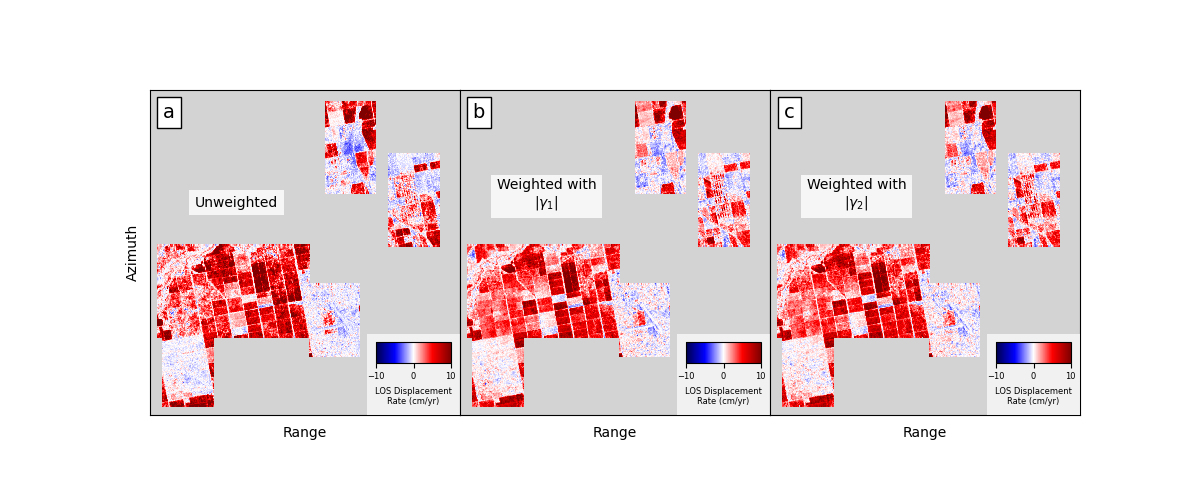

In [ ]:
# This is Figure 13. 
label_x = 0.08
label_y = 0.90
props = dict(boxstyle='square',facecolor='white',edgecolor='black')

fig,axs = plt.subplots(1,3,figsize=(12,5))
plt.subplots_adjust(wspace=0.0,hspace=0.0)

ax = axs[0]
im = ax.imshow(uw_filt,cmap=CM2,aspect=aspect_rat,vmin=-10,vmax=10,interpolation='none')
cax = ax.inset_axes([0.7,0.0,0.3,0.25]); cax.set_yticks([]); cax.set_xticks([])
cax.set_facecolor('white')
for spine in cax.spines.values():
    spine.set_visible(False)
cax.patch.set_alpha(0.7)
inner_ax = cax.inset_axes([0.1, 0.65, 0.8, 0.25])
cbar = plt.colorbar(im, cax=inner_ax, orientation='horizontal')
cbar.set_label('LOS Displacement\nRate (cm/yr)',fontsize=6)
cbar.ax.tick_params(labelsize=6)
ax.set_xticks([]); ax.set_yticks([])
ax.set_xlim(4600,300)
ax.set_ylim(1300,50)
ax.set_ylabel('Azimuth'); ax.set_xlabel('Range')
ax.text(3400,500,'Unweighted',fontsize=10,ha='center',bbox=dict(facecolor='white',edgecolor='none',alpha=0.8))
ax.text(label_x, label_y, 'a', bbox=props, fontsize=14,
        ha='right', va='bottom', transform=ax.transAxes)

ax = axs[1]
im = ax.imshow(w_coh1_filt,cmap=CM2,aspect=aspect_rat,vmin=-10,vmax=10,interpolation='none')
cax = ax.inset_axes([0.7,0.0,0.3,0.25]); cax.set_yticks([]); cax.set_xticks([])
cax.set_facecolor('white')
for spine in cax.spines.values():
    spine.set_visible(False)
cax.patch.set_alpha(0.7)
inner_ax = cax.inset_axes([0.1, 0.65, 0.8, 0.25])
cbar = plt.colorbar(im, cax=inner_ax, orientation='horizontal')
cbar.set_label('LOS Displacement\nRate (cm/yr)',fontsize=6)
cbar.ax.tick_params(labelsize=6)
ax.set_xticks([]); ax.set_yticks([])
ax.set_xlim(4600,300)
ax.set_ylim(1300,50)
ax.set_xlabel('Range')
ax.text(3400,500,'Weighted with\n$|\gamma_{1}|$',fontsize=10,ha='center',bbox=dict(facecolor='white',edgecolor='none',alpha=0.8))
ax.text(label_x, label_y, 'b', bbox=props, fontsize=14,
        ha='right', va='bottom', transform=ax.transAxes)

ax = axs[2]
im = ax.imshow(w_coh2_filt,cmap=CM2,aspect=aspect_rat,vmin=-10,vmax=10,interpolation='none')
cax = ax.inset_axes([0.7,0.0,0.3,0.25]); cax.set_yticks([]); cax.set_xticks([])
cax.set_facecolor('white')
for spine in cax.spines.values():
    spine.set_visible(False)
cax.patch.set_alpha(0.7)
inner_ax = cax.inset_axes([0.1, 0.65, 0.8, 0.25])
cbar = plt.colorbar(im, cax=inner_ax, orientation='horizontal')
cbar.set_label('LOS Displacement\nRate (cm/yr)',fontsize=6)
cbar.ax.tick_params(labelsize=6)
ax.set_xticks([]); ax.set_yticks([])
ax.set_xlim(4600,300)
ax.set_ylim(1300,50)
ax.set_xlabel('Range')
ax.text(3400,500,'Weighted with\n$|\gamma_{2}|$',fontsize=10,ha='center',bbox=dict(facecolor='white',edgecolor='none',alpha=0.8))
ax.text(label_x, label_y, 'c', bbox=props, fontsize=14,
        ha='right', va='bottom', transform=ax.transAxes)

plt.show()
#plt.savefig('disp_rates.png',transparent=True,bbox_inches='tight',dpi=500)

In [10]:
# filter the rate differences slightly, for display purposes
m1_m2 = nan_gaussian_filter(((weighted_rates_m1-weighted_rates_m2)*rad2cm), sigma=2)
uw_m2 = nan_gaussian_filter(((unweighted_rates-weighted_rates_m2)*rad2cm), sigma=2)
uw_m1 = nan_gaussian_filter(((unweighted_rates-weighted_rates_m1)*rad2cm), sigma=2)

In [11]:
# make a colormap where Nans are gray (new color scheme for rate diffs so can't use the one defined above)
CM3 = plt.get_cmap('PuOr').copy()
CM3.set_bad(color='lightgray')  # nans are now gray

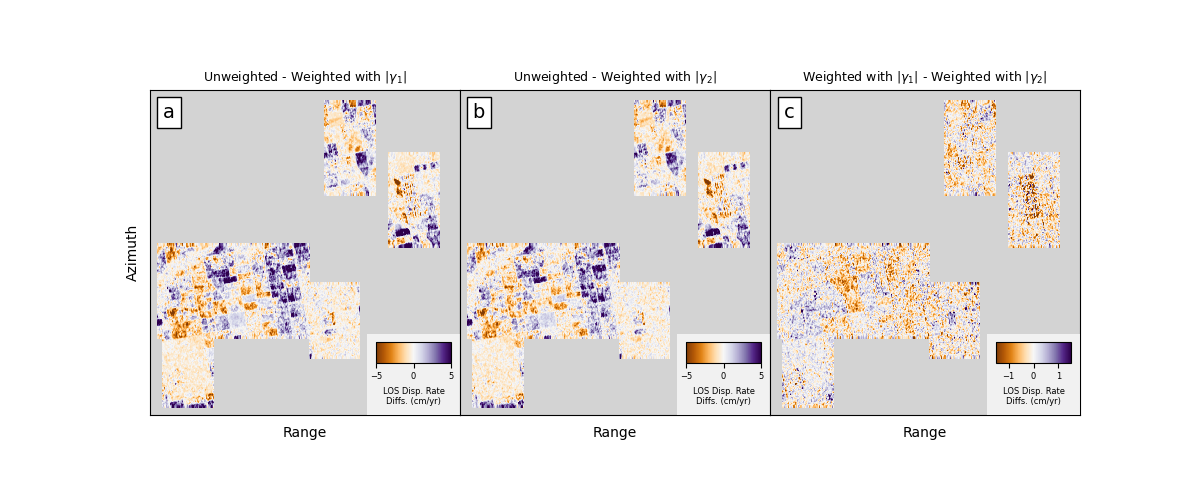

In [ ]:
# This is Figure 14.
label_x = 0.08
label_y = 0.90
props = dict(boxstyle='square',facecolor='white',edgecolor='black')

fig,axs = plt.subplots(1,3,figsize=(12,5))
plt.subplots_adjust(wspace=0.0,hspace=0.0)

ax = axs[0]
im = ax.imshow(uw_m1,cmap=CM3,aspect=aspect_rat,vmin=-5,vmax=5,interpolation='none')
cax = ax.inset_axes([0.7,0.0,0.3,0.25]); cax.set_yticks([]); cax.set_xticks([])
cax.set_facecolor('white')
for spine in cax.spines.values():
    spine.set_visible(False)
cax.patch.set_alpha(0.7)
inner_ax = cax.inset_axes([0.1, 0.65, 0.8, 0.25])
cbar = plt.colorbar(im, cax=inner_ax, orientation='horizontal')
cbar.set_label('LOS Disp. Rate\nDiffs. (cm/yr)',fontsize=6)
cbar.ax.tick_params(labelsize=6)
ax.set_xticks([]); ax.set_yticks([])
ax.set_xlim(4600,300)
ax.set_ylim(1300,50)
ax.set_ylabel('Azimuth'); ax.set_xlabel('Range')
ax.set_title('Unweighted - Weighted with $|\gamma_{1}|$',fontsize=9)
#ax.text(3400,500,'Unweighted - Weighted with $|\gamma_{1}|$',fontsize=8,ha='center',bbox=dict(facecolor='white',edgecolor='none',alpha=0.8))
ax.text(label_x, label_y, 'a', bbox=props, fontsize=14,
        ha='right', va='bottom', transform=ax.transAxes)

ax = axs[1]
im = ax.imshow(uw_m2,cmap=CM3,aspect=aspect_rat,vmin=-5,vmax=5,interpolation='none')
cax = ax.inset_axes([0.7,0.0,0.3,0.25]); cax.set_yticks([]); cax.set_xticks([])
cax.set_facecolor('white')
for spine in cax.spines.values():
    spine.set_visible(False)
cax.patch.set_alpha(0.7)
inner_ax = cax.inset_axes([0.1, 0.65, 0.8, 0.25])
cbar = plt.colorbar(im, cax=inner_ax, orientation='horizontal')
cbar.set_label('LOS Disp. Rate\nDiffs. (cm/yr)',fontsize=6)
cbar.ax.tick_params(labelsize=6)
ax.set_xticks([]); ax.set_yticks([])
ax.set_xlim(4600,300)
ax.set_ylim(1300,50)
ax.set_xlabel('Range')
ax.set_title('Unweighted - Weighted with $|\gamma_{2}|$',fontsize=9,wrap=False)
#ax.text(3400,500,'Unweighted - Weighted with\n$|\gamma_{2}|$',fontsize=8,ha='center',bbox=dict(facecolor='white',edgecolor='none',alpha=0.8))
ax.text(label_x, label_y, 'b', bbox=props, fontsize=14,
        ha='right', va='bottom', transform=ax.transAxes)

ax = axs[2]
im = ax.imshow(m1_m2,cmap=CM3,aspect=aspect_rat,vmin=-1.5,vmax=1.5,interpolation='none')
cax = ax.inset_axes([0.7,0.0,0.3,0.25]); cax.set_yticks([]); cax.set_xticks([])
cax.set_facecolor('white')
for spine in cax.spines.values():
    spine.set_visible(False)
cax.patch.set_alpha(0.7)
inner_ax = cax.inset_axes([0.1, 0.65, 0.8, 0.25])
cbar = plt.colorbar(im, cax=inner_ax, orientation='horizontal')
cbar.set_label('LOS Disp. Rate\nDiffs. (cm/yr)',fontsize=6)
cbar.ax.tick_params(labelsize=6)
ax.set_xticks([]); ax.set_yticks([])
ax.set_xlim(4600,300)
ax.set_ylim(1300,50)
ax.set_xlabel('Range')
ax.set_title('Weighted with $|\gamma_{1}|$ - Weighted with $|\gamma_{2}|$',fontsize=9,wrap=False)
#ax.text(3400,500,'Weighted with\n$|\gamma_{1}|$ - Weighted with\n$|\gamma_{2}|$',fontsize=8,ha='center',bbox=dict(facecolor='white',edgecolor='none',alpha=0.8))
ax.text(label_x, label_y, 'c', bbox=props, fontsize=14,
        ha='right', va='bottom', transform=ax.transAxes)
plt.show()
# plt.savefig('disp_rate_diffs.png',transparent=True, bbox_inches='tight',dpi=500)